In [12]:
import os
import pandas as pd
import numpy as np

ROOT_DIR = os.path.dirname(os.getcwd())  

df = pd.read_csv(os.path.join(ROOT_DIR, "results", "admet_results_cv.csv"))  

# rank within each task
def get_rank_direction(metric):
    # ROC_AUC, PR_AUC, Spearman: higher is better; MAE: lower is better
    if any(m in metric for m in ["ROC_AUC", "PR_AUC", "Spearman"]):
        return False # ascending=False, larger is better
    else:
        return True # ascending=True, smaller is better

df["rank"] = np.nan

for (task_group, data_name, metric), sub in df.groupby(["task_group", "data_name", "metric"]):
    # decide sorting direction based on the metric
    asc = get_rank_direction(metric)
    # sort and assign ranks
    idx = sub.sort_values("mean", ascending=asc).index
    df.loc[idx, "rank"] = np.arange(1, len(idx) + 1)

print(df.head())


   task_group data_name   metric   model   mean    std  rank
0  Absorption     Caco2      MAE  D-MPNN  0.316  0.011   3.0
1  Absorption       HIA  ROC_AUC  D-MPNN  0.980  0.019   2.0
2  Absorption       Pgp  ROC_AUC  D-MPNN  0.935  0.019   5.0
3  Absorption     Bioav  ROC_AUC  D-MPNN  0.695  0.067   4.0
4  Absorption      Lipo      MAE  D-MPNN  0.387  0.013   3.0


In [13]:
# Mean
group_rank_mean_df = (
    df.groupby(["task_group", "model"])["rank"]
    .mean()
    .unstack()
)
print(group_rank_mean_df)


# Median
group_rank_median_df = (
    df.groupby(["task_group", "model"])["rank"]
    .median()
    .unstack()
)
print(group_rank_median_df)


model           D-MPNN  D-MPNN+Desc  D-MPNN+MMB+Desc      Desc       GCN  \
task_group                                                                 
Absorption    3.333333     1.333333         3.166667  3.166667  6.666667   
Distribution  3.333333     1.333333         3.000000  3.666667  6.666667   
Excretion     1.000000     3.333333         3.000000  2.666667  6.666667   
Metabolism    2.666667     2.500000         2.666667  3.833333  6.666667   
Toxicity      1.500000     2.250000         3.500000  3.750000  5.500000   

model         GCN+MMB+Desc       MMB  
task_group                            
Absorption        4.000000  6.333333  
Distribution      3.666667  6.333333  
Excretion         5.000000  6.333333  
Metabolism        4.166667  5.500000  
Toxicity          5.000000  6.500000  
model         D-MPNN  D-MPNN+Desc  D-MPNN+MMB+Desc  Desc  GCN  GCN+MMB+Desc  \
task_group                                                                    
Absorption       3.0          1.0   

# Radar chart (rank)

## mean

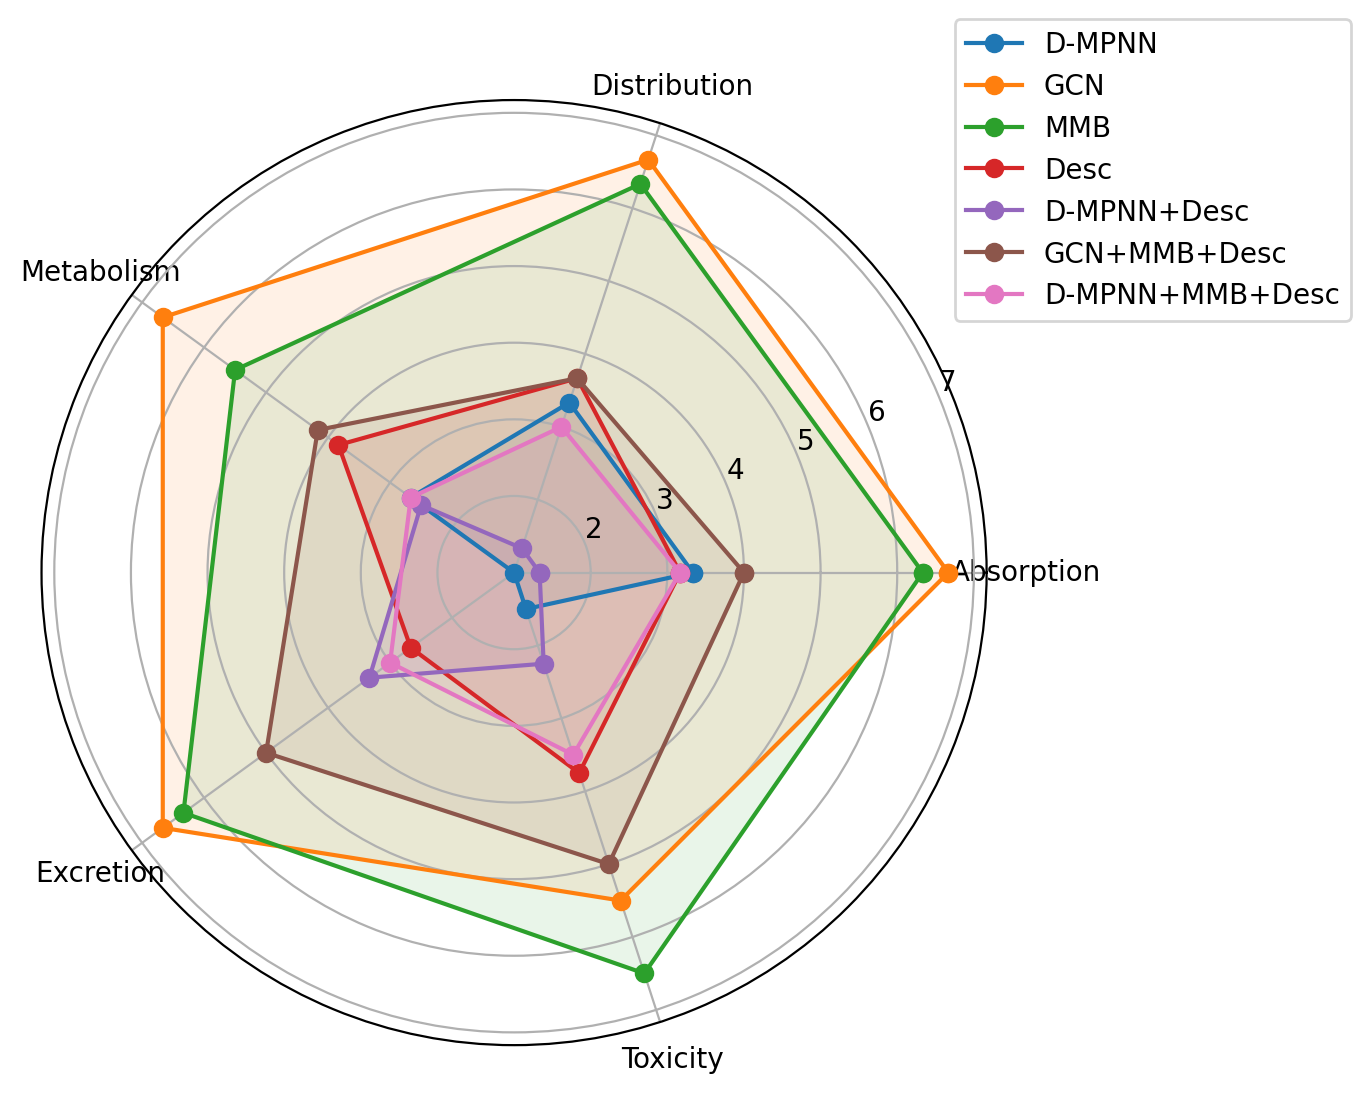

In [14]:
import matplotlib.pyplot as plt
import numpy as np

models = ["D-MPNN", "GCN", "MMB", "Desc", "D-MPNN+Desc", "GCN+MMB+Desc", "D-MPNN+MMB+Desc"]
task_groups = ["Absorption", "Distribution", "Metabolism", "Excretion", "Toxicity"]

group_rank_df = group_rank_mean_df.loc[task_groups, models]

labels = task_groups
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(7, 7), dpi=200)
ax = plt.subplot(111, polar=True)

for model in models:
    values = group_rank_df[model].values.tolist()
    values += values[:1]
    ax.plot(angles, values, label=model, marker='o')
    ax.fill(angles, values, alpha=0.1)

ax.set_thetagrids(np.degrees(angles[:-1]), labels)
ax.set_ylim(1, group_rank_df.max().max() + 0.5)
# ax.set_title("ADMET Groups Model Rank Radar Chart", size=15)
ax.legend(loc="upper right", bbox_to_anchor=(1.4, 1.1))
plt.tight_layout()
plt.show()


## median

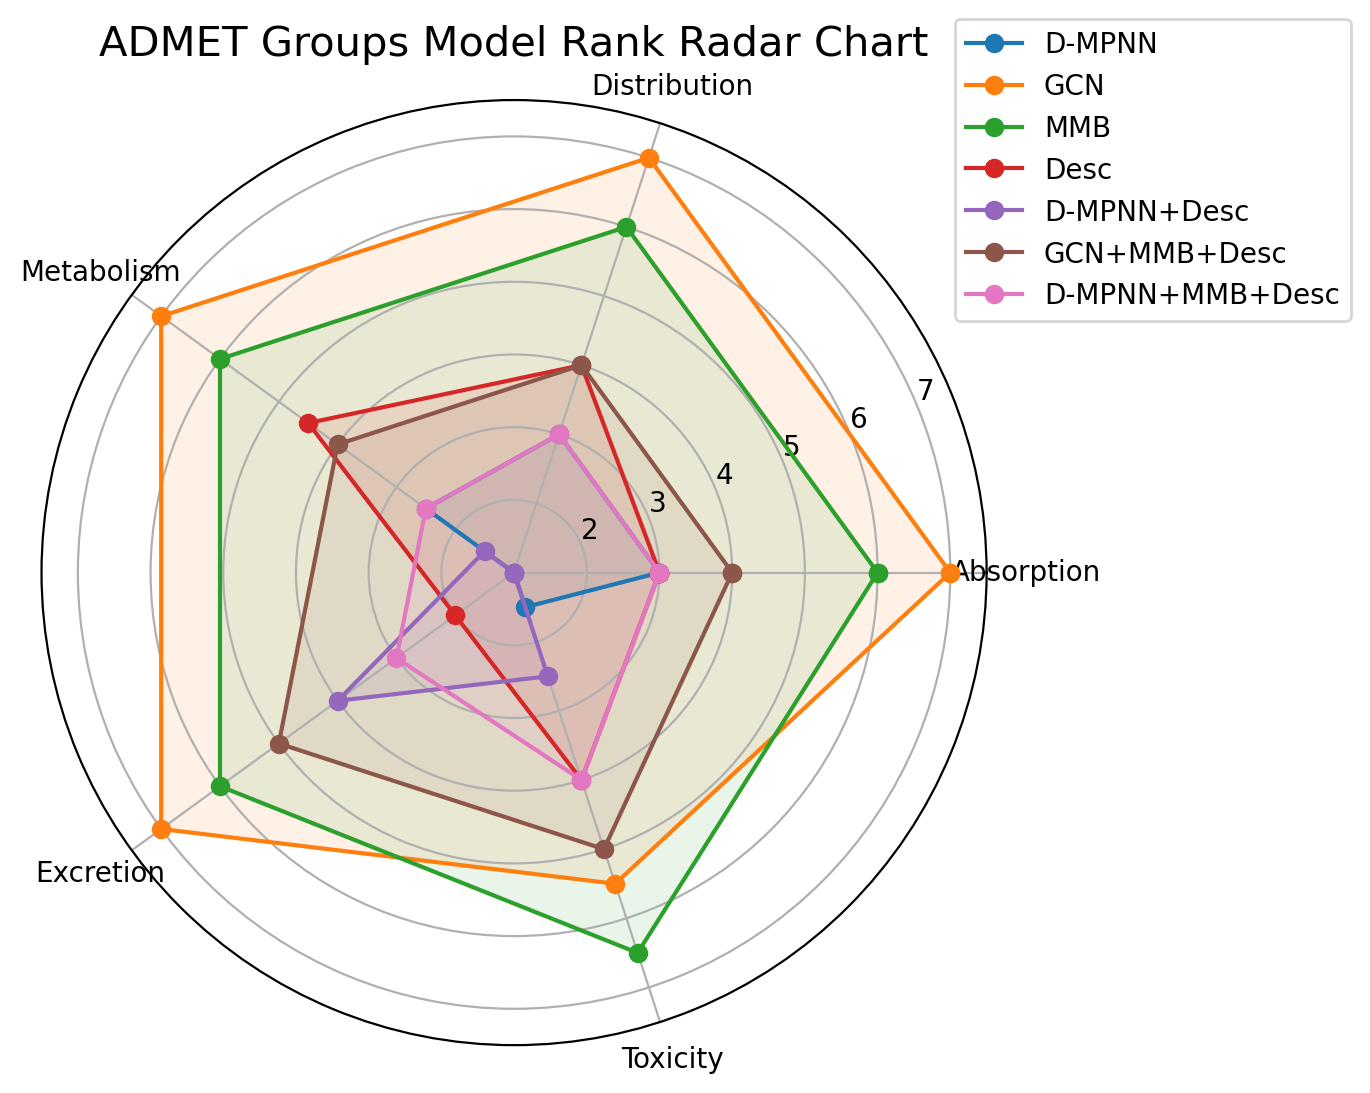

In [15]:
models_to_plot = ["D-MPNN", "GCN", "MMB", "Desc", "D-MPNN+Desc", "GCN+MMB+Desc", "D-MPNN+MMB+Desc"]
task_groups = ["Absorption", "Distribution", "Metabolism", "Excretion", "Toxicity"]

# 確保順序正確
group_rank_df = group_rank_median_df.loc[task_groups, models_to_plot]

labels = task_groups
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]  # 關閉迴圈

plt.figure(figsize=(7, 7), dpi=200)
ax = plt.subplot(111, polar=True)

for model in models_to_plot:
    values = group_rank_df[model].values.tolist()
    values += values[:1]
    ax.plot(angles, values, label=model, marker='o')
    ax.fill(angles, values, alpha=0.1)

ax.set_thetagrids(np.degrees(angles[:-1]), labels)
ax.set_ylim(1, group_rank_df.max().max() + 0.5)  # 1:表示第一名
ax.set_title("ADMET Groups Model Rank Radar Chart", size=15)
ax.legend(loc="upper right", bbox_to_anchor=(1.4, 1.1))
plt.tight_layout()
plt.show()




# Heatmap (rank)

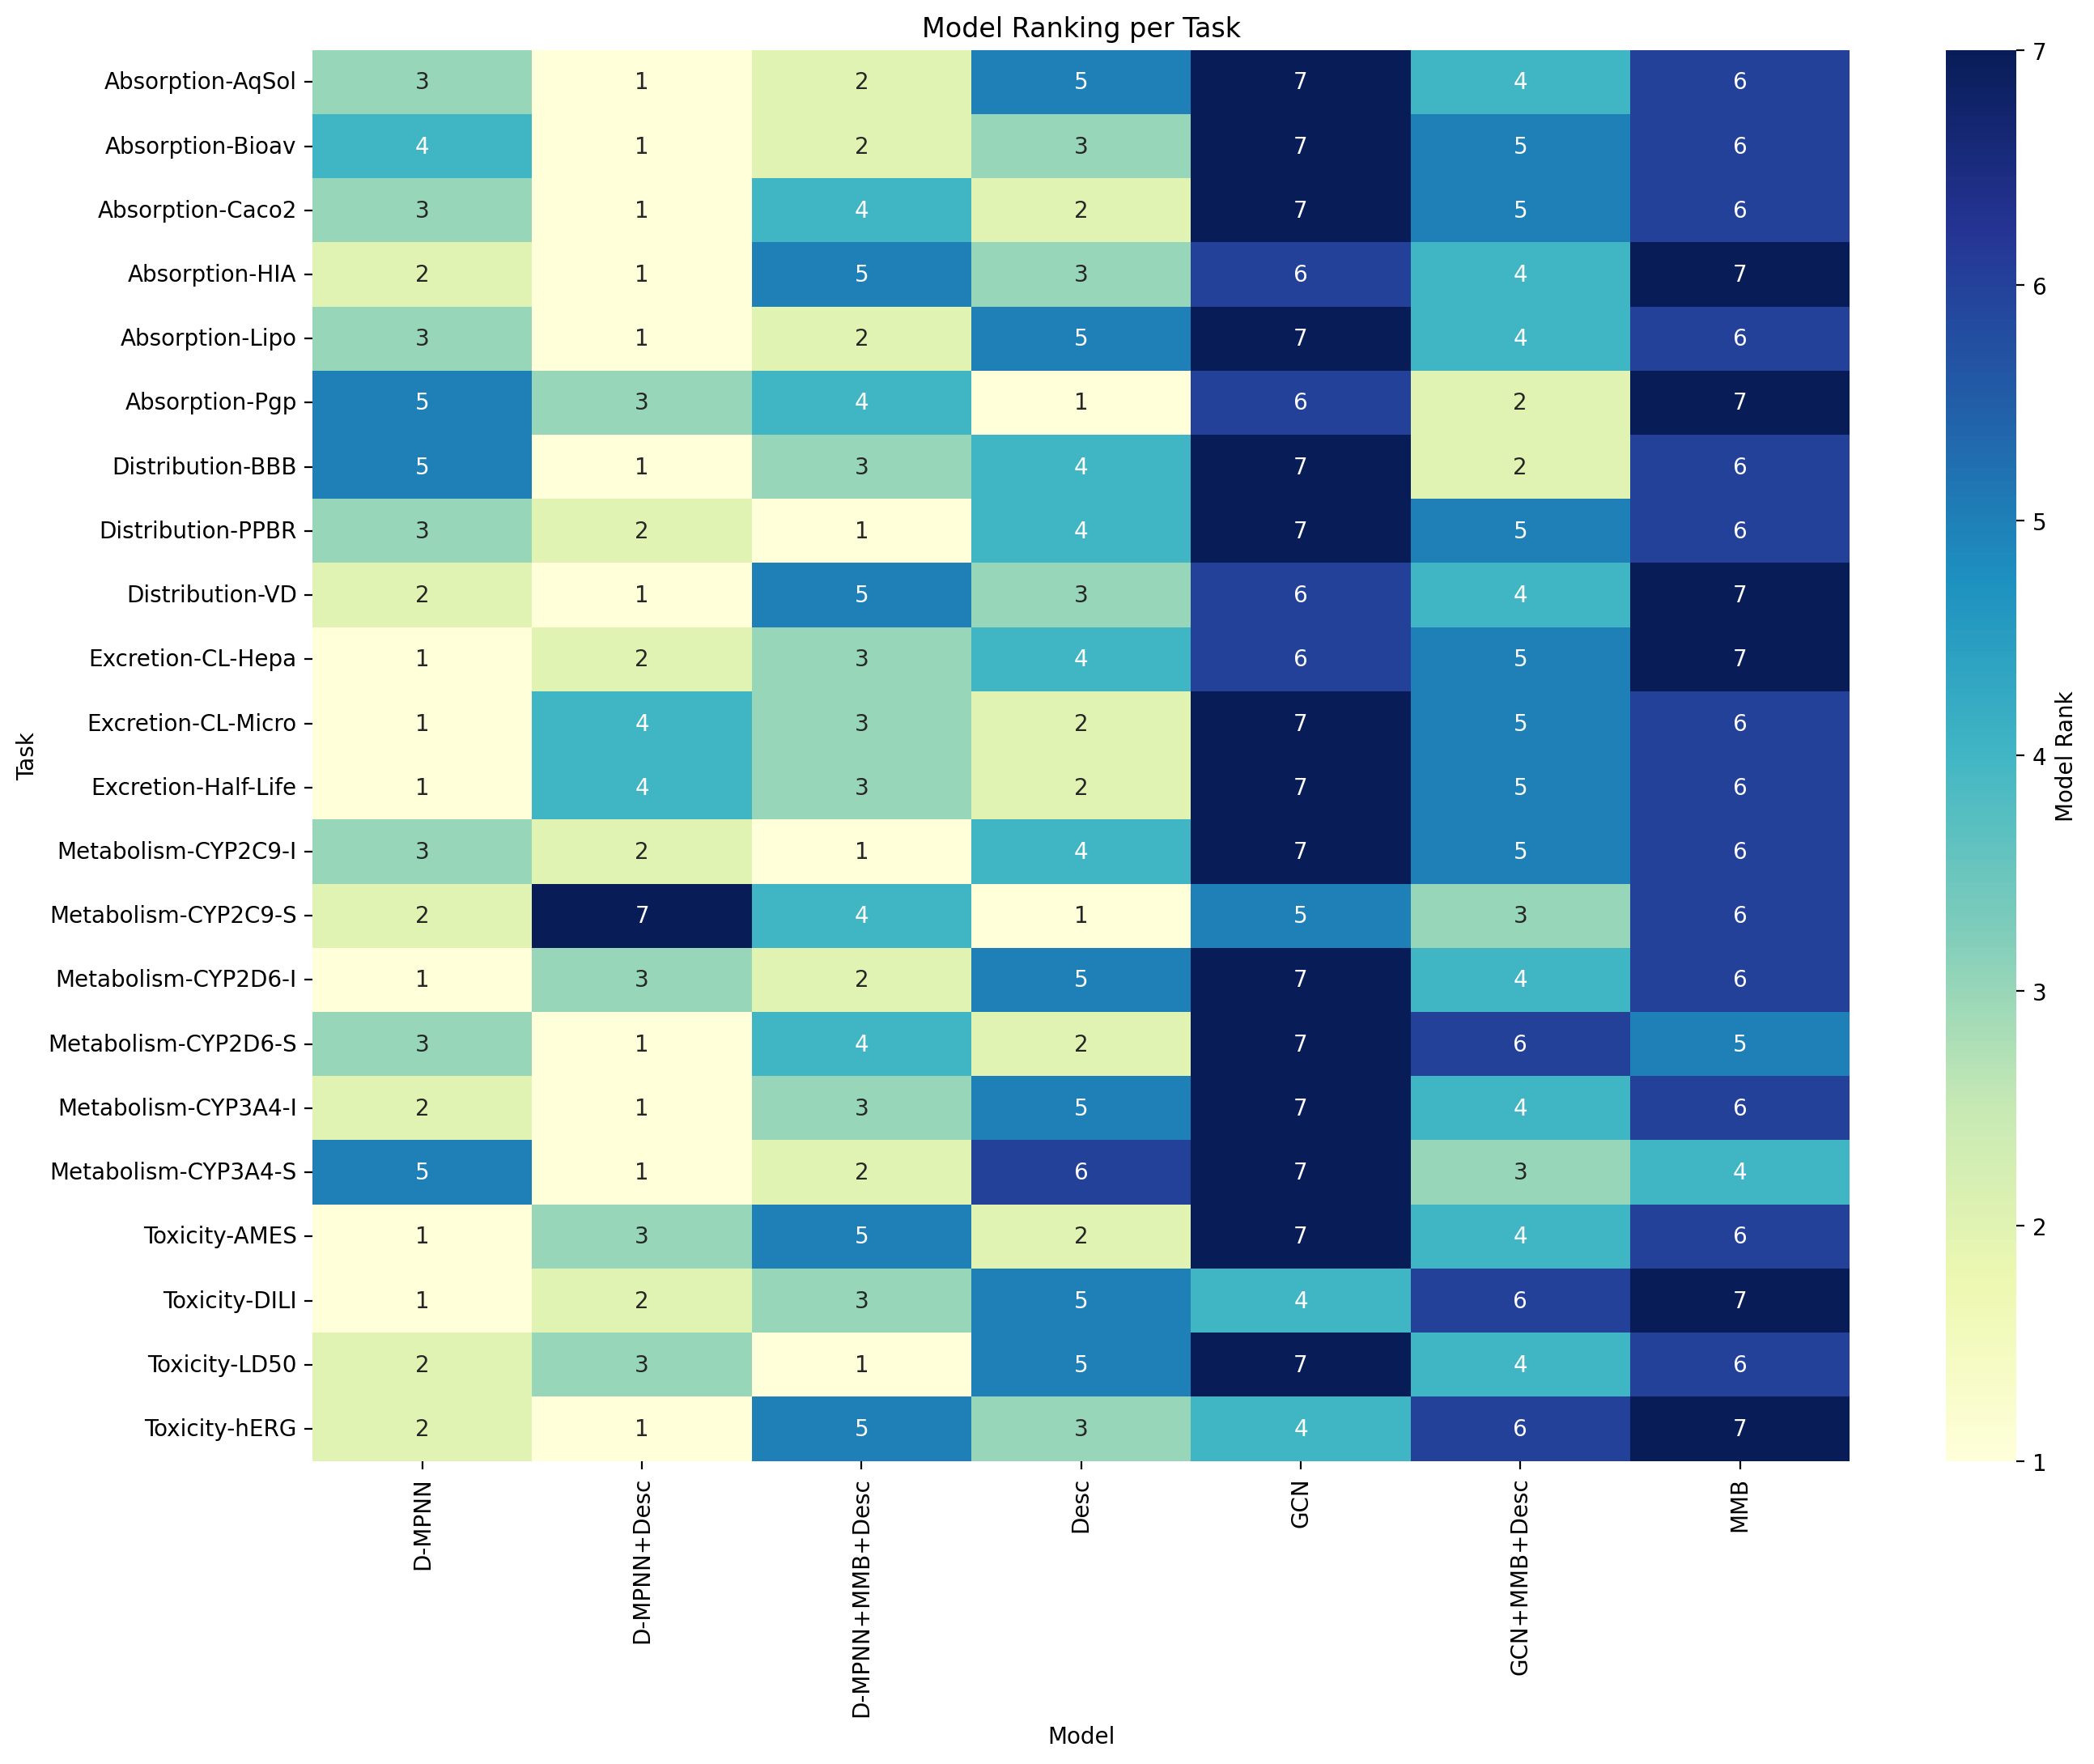

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

heatmap_df = (
    # df.pivot_table(index=["task_group", "data_name", "metric"], columns="model", values="rank")
    df.pivot_table(index=["task_group", "data_name"], columns="model", values="rank")
)

plt.figure(figsize=(14, int(len(heatmap_df)/2)), dpi=200)
sns.heatmap(heatmap_df, annot=True, fmt=".0f", cmap="YlGnBu", cbar_kws={'label': 'Model Rank'})
plt.title("Model Ranking per Task")
plt.ylabel("Task")
plt.xlabel("Model")
plt.tight_layout()
plt.show()
